In [3]:
import os
import matplotlib.pylab as plt
import stpsf
import numpy as np
import matplotlib
import pandas as pd


# Characterization of Roman PSF across the focal plane

This notebook characterizes the Roman Wide Field Instrument (WFI) point-spread function (PSF) using the final STPSF-ready post-SCIPA phase maps. The analysis focuses on the spatial variation of the PSF across the WFI field of view and provides a comparison with the PSF model available in previous STPSF versions.

We characterize the PSF using encircled energy (EE) and full width at half maximum (FWHM), evaluating their variation across the WFI field for representative filters and field positions. These measurements provide a quantitative description of the field dependence of the Roman WFI PSF and help assess the impact of the updated optical model.

The results are also compared with the corresponding PSF characteristics from the previous STPSF model to highlight changes introduced by the updated post-SCIPA phase maps.

The phase-map generation and reconstruction methodology is described separately in the [Post-SCIPA Phase Maps documentation](STPSF_Roman_PostSCIPA).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import stpsf
import pysiaf
import gc
import os

# ---------------- USER SETTINGS ----------------
FILTER            = 'F129'     # Roman WFI filter
OVERSAMPLE        = 4          # oversampling used to build the PSF
FOV_ARCSEC        = 3.0        # PSF stamp size
EE_RADIUS_ARCSEC  = 0.3        # radius at which EE is evaluated (variable)
N_GRID            = 5          # NxN field points per detector
MARGIN_PIX        = 4          # keep grid points off the very edge of the SCA
MONOCHROMATIC_UM  = None       # e.g. 1.29 for monochromatic (fast); None = full bandpass (slow/heavy)
CSV_PATH          = 'roman_psf_results.csv' # Let's save the results so we don't re-run this cell for different visualizations
# -------------------------------------------------

siaf = pysiaf.Siaf('Roman')

Then we start our calculations per detector. Note that in this case we are saving the results in a separate CSV file. In this way you can play around with different visualizations without having to re-run the entire set of calculations.

In [ ]:
# --- figure out what's already done, and clean up any partial detector calculation, if any ---
completed_scas = set()
if os.path.exists(CSV_PATH):
    existing = pd.read_csv(CSV_PATH)
    counts = existing.groupby('sca').size()
    completed_scas = set(counts[counts == N_GRID * N_GRID].index)
    partial_scas = set(counts[counts != N_GRID * N_GRID].index)
    if partial_scas:
        print(f'Removing incomplete rows for: {sorted(partial_scas)}')
        existing = existing[~existing['sca'].isin(partial_scas)]
        existing.to_csv(CSV_PATH, index=False)
    print(f'Already complete: {sorted(completed_scas) if completed_scas else "none"}')

for n in range(1, 19):
    sca = f'SCA{n:02d}'
    if sca in completed_scas:
        print(f'{sca} already in {CSV_PATH}, skipping')
        continue

    ap_name = f'WFI{n:02d}_FULL'
    ap = siaf[ap_name]

    wfi = stpsf.roman.WFI()      # fresh instrument instance per detector
    wfi.filter = FILTER
    wfi.detector = sca

    xmin, xmax = MARGIN_PIX, ap.XSciSize - MARGIN_PIX
    ymin, ymax = MARGIN_PIX, ap.YSciSize - MARGIN_PIX
    xs = np.linspace(xmin, xmax, N_GRID)
    ys = np.linspace(ymin, ymax, N_GRID)

    rows = []
    for i, y in enumerate(ys):
        for j, x in enumerate(xs):
            wfi.detector_position = (x, y)

            if MONOCHROMATIC_UM is not None:
                psf = wfi.calc_psf(oversample=OVERSAMPLE, fov_arcsec=FOV_ARCSEC,
                                    monochromatic=MONOCHROMATIC_UM * 1e-6)
            else:
                psf = wfi.calc_psf(oversample=OVERSAMPLE, fov_arcsec=FOV_ARCSEC)

            ee_func  = stpsf.measure_ee(psf, ext='OVERSAMP')
            ee_val   = ee_func(EE_RADIUS_ARCSEC)
            fwhm_val = stpsf.measure_fwhm(psf, ext='OVERSAMP')
            telx, tely = ap.sci_to_tel(x, y)

            rows.append(dict(sca=sca, i=i, j=j, x_pix=x, y_pix=y,
                              telx=telx, tely=tely, ee=ee_val, fwhm=fwhm_val))

            psf.close()
            del psf

        gc.collect()

    # write this detector's 25 rows to disk right away
    df_det = pd.DataFrame(rows)
    write_header = not os.path.exists(CSV_PATH)
    df_det.to_csv(CSV_PATH, mode='a', header=write_header, index=False)

    print(f'{sca} done, saved to {CSV_PATH}')

    del wfi
    gc.collect()

print('All detectors complete.')

Then we read the file and plot the results. 

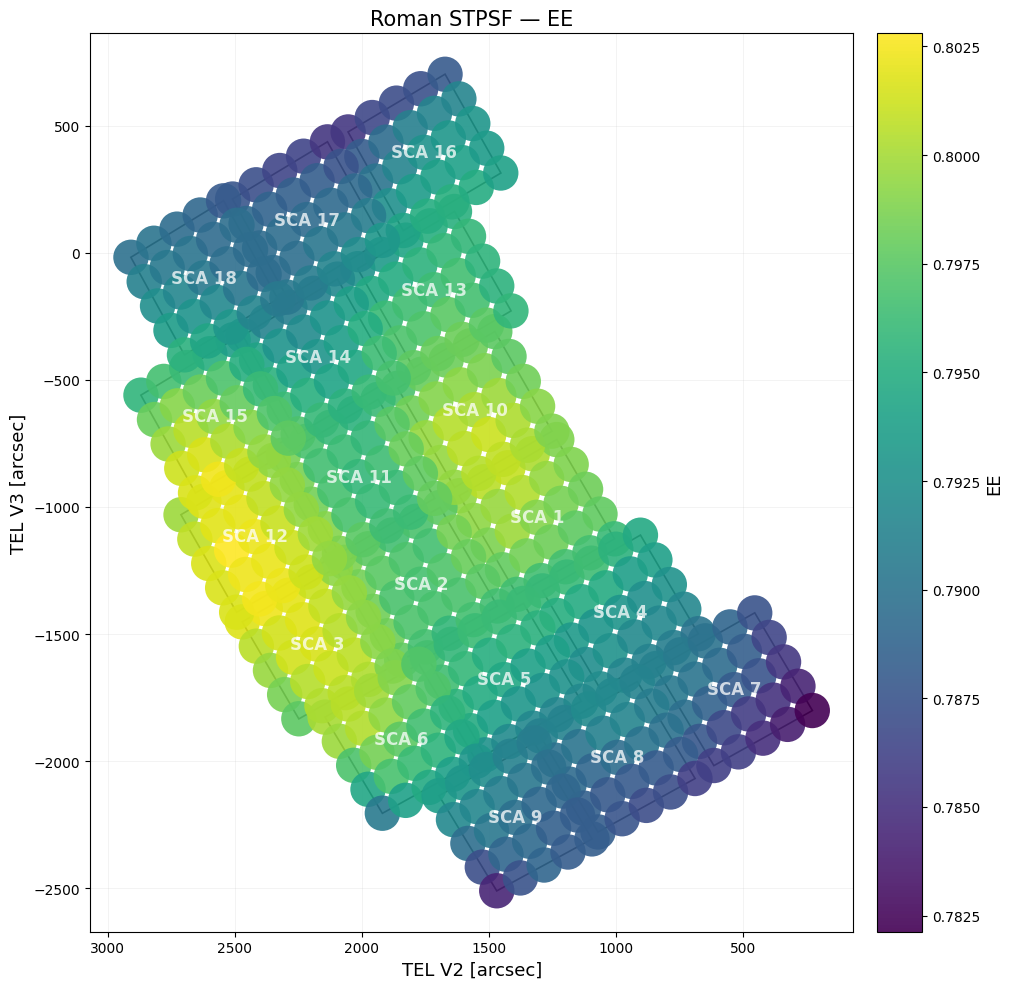

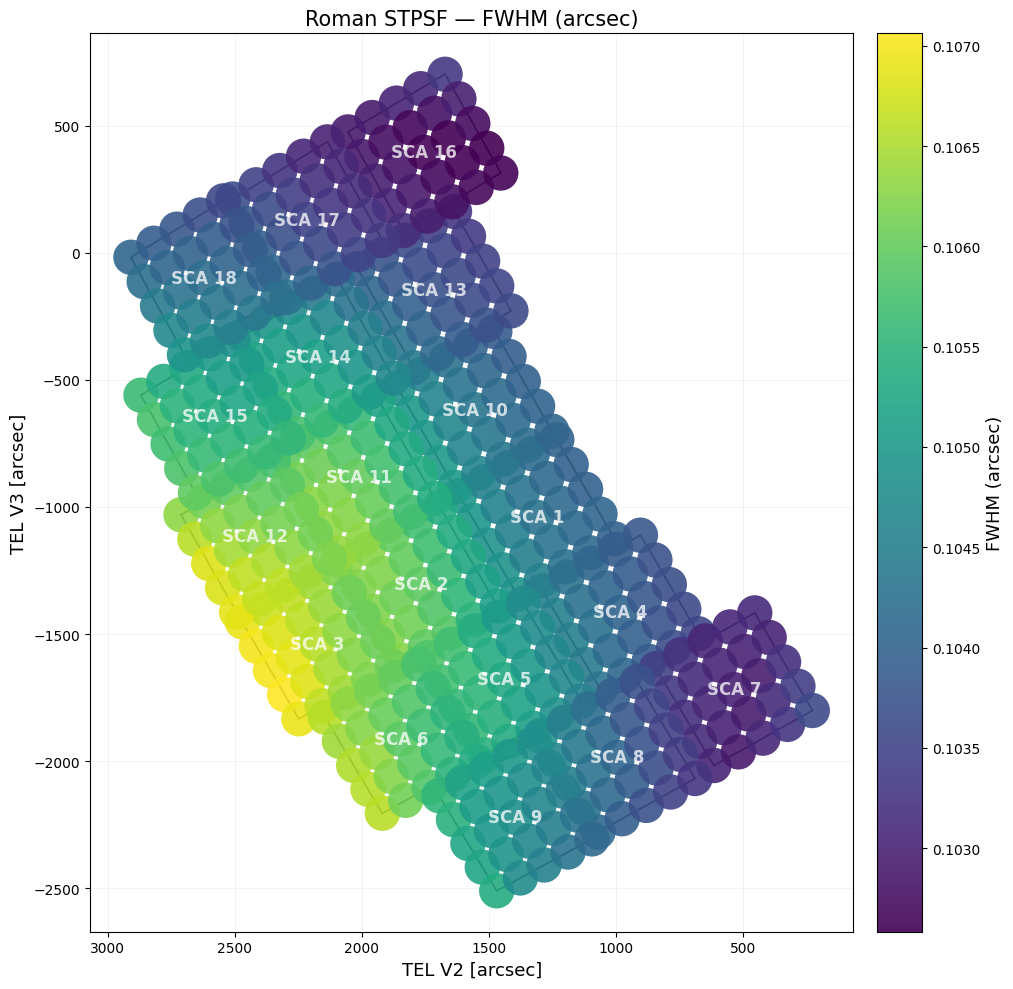

In [13]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import pysiaf
# ------------------------------------------------------------
# Read results
# ------------------------------------------------------------
df = pd.read_csv("roman_psf_results.csv")
siaf = pysiaf.Siaf("Roman")
df["sca_num"] = df["sca"].str.extract(r"(\d+)").astype(int)
scas = sorted(df["sca_num"].unique())
# ------------------------------------------------------------
# Get SCA footprints in TEL coordinates
# ------------------------------------------------------------
footprints = {}
for n in scas:
    ap = siaf[f"WFI{n:02d}_FULL"]
    x = np.array([1, ap.XSciSize, ap.XSciSize, 1])
    y = np.array([1, 1, ap.YSciSize, ap.YSciSize])
    telx, tely = ap.sci_to_tel(x, y)
    footprints[n] = np.column_stack((telx, tely))
# ------------------------------------------------------------
# Plot function
# ------------------------------------------------------------
def plot_psf(quantity, label):
    fig, ax = plt.subplots(figsize=(13, 10))
    # --------------------------------------------------------
    # Color scale
    # --------------------------------------------------------
    vmin = df[quantity].min()
    vmax = df[quantity].max()
    # --------------------------------------------------------
    # Plot detector footprints
    # --------------------------------------------------------
    for n in scas:
        footprint = footprints[n]
        ax.add_patch(
            Polygon(
                footprint,
                closed=True,
                facecolor="none",
                edgecolor="black",
                linewidth=1.2,
                zorder=2
            )
        )
    # --------------------------------------------------------
    # Plot the 5 x 5 measurements
    #
    # Large markers intentionally overlap to make the
    # distribution look more continuous.
    # --------------------------------------------------------
    sc = ax.scatter(
        df["telx"],
        df["tely"],
        c=df[quantity],
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        s=650,                 # increase/decrease for smoothness
        marker="o",
        edgecolor="none",
        alpha=0.90,
        zorder=3
    )
    # --------------------------------------------------------
    # Detector labels
    # --------------------------------------------------------
    for n in scas:
        footprint = footprints[n]
        cx = footprint[:, 0].mean()
        cy = footprint[:, 1].mean()
        ax.text(
            cx,
            cy,
            f"SCA {n}",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="white",
            alpha=0.75,
            zorder=5
        )
    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------
    cbar = fig.colorbar(
        sc,
        ax=ax,
        pad=0.02,
        fraction=0.045
    )
    cbar.set_label(
        label,
        fontsize=13
    )
    # --------------------------------------------------------
    # Axes
    # --------------------------------------------------------
    ax.set_aspect("equal")
    ax.set_xlabel(
        "TEL V2 [arcsec]",
        fontsize=13
    )
    ax.set_ylabel(
        "TEL V3 [arcsec]",
        fontsize=13
    )
    ax.set_title(
        f"Roman STPSF — {label}",
        fontsize=15
    )
    # --------------------------------------------------------
    # Limits
    # --------------------------------------------------------
    xy = np.vstack(
        list(footprints.values())
    )
    margin = 0.05 * max(
        xy[:, 0].max() - xy[:, 0].min(),
        xy[:, 1].max() - xy[:, 1].min()
    )
    ax.set_xlim(
        xy[:, 0].min() - margin,
        xy[:, 0].max() + margin
    )
    ax.set_ylim(
        xy[:, 1].min() - margin,
        xy[:, 1].max() + margin
    )
    # Roman TEL convention: +V2 increases to the left
    ax.invert_xaxis()
    ax.grid(
        alpha=0.15,
        linewidth=0.7
    )
    plt.tight_layout()
    return fig, ax


# ============================================================
# EE
# ============================================================
fig_ee, ax_ee = plot_psf(
    "ee",
    "EE"
)
plt.show()
# ============================================================
# FWHM
# ============================================================
fig_fwhm, ax_fwhm = plot_psf(
    "fwhm",
    "FWHM (arcsec)"
)
plt.show()

For additional information about the orientation of the telescope and instruments with respect to the Roman observatory see [Roman coordinate system](https://roman-docs.stsci.edu/data-handbook/wfi-data-levels-and-products/coordinate-systems) 

> **Key Result**
>
> EE and FWHM show multi-field variations, however, these variations are quantitatively small

## Comparison between STPSF v2.2.0 and STPSF v2.3.0

The primary change in the Roman optical model between STPSF v2.2.0 and v2.3.0 is the increased field sampling provided by the post-SCIPA model.The previous model represented each detector using five field positions, whereas the new model represents each detector using a 5×5 grid of 25 field positions.

The figures below compare the resulting EE and FWHM distributions across the Roman focal plane. The denser 5×5 sampling provides a more detailed representation of the spatial variation of the PSF properties across the WFI field.

**Figure 8 — Encircled Energy fraction Multi-field variations. STPSF v2.2.0**

<img src="./roman_figures/ee-fov_v2_2_0.png"
     alt="EE variations"
     width="800">

**Caption**

*Encircled Energy fraction Multi-field variations. STPSF v2.2.0*

**Figure 9 — Roman FWHM  Multi-field variations. STPSF v2.2.0**

<img src="./roman_figures/fwhm-fov_v2_2_0.png"
     alt="FWHM variations"
     width="800">

**Caption**

*Roman FWHMn Multi-field variations. STPSF v2.2.0*

## Conclusions

The post-SCIPA Roman optical delivery provides substantially improved field sampling compared with the optical model used in previous STPSF releases.

We developed a compact representation of this model using Zernike coefficients through Z210 together with detector-specific high-frequency residual maps.
 
This approach:

- increases the field sampling from 5 to 25 positions per detector;
- preserves detector-dependent high-spatial-frequency structure;
- efficiently represents the wavelength dependence of the wavefront;
- reconstructs the original post-SCIPA wavefront maps with an RMS residual of approximately 12 nm; and
- substantially reduces the amount of optical reference data that must be distributed with STPSF.

The resulting model provides STPSF users with a substantially more densely sampled representation of the Roman WFI optical wavefront while maintaining a practical reference-data package.